In [36]:
#Questions in which similar task had to be performed have been grouped together.

# Practice Q: 1 - 2 / Assignment Q:1/ Mini-Project 3

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [23]:
iris = pd.read_csv('Iris.csv')
iris_original = iris.copy()
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
iris = iris.drop(['Id'], axis = 1)
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [25]:
iris['Species'].value_counts()

# Here, we can see that this column is the label for this dataset.
# For unsupervised learning, we should exclude the label to see how well the model functions blindly.
# Hence, even though we know there should be 3 clusters, I will run the code ignoring this fact & find the best no. of clusters organically through the model.

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Text(0.5, 1.0, 'Elbow Method')

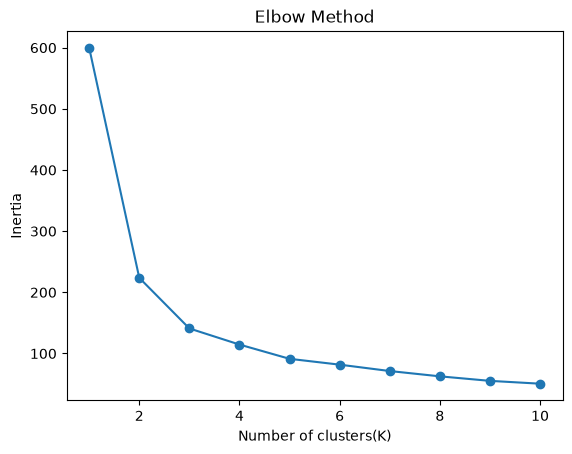

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(1,11)

for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters(K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')



In [27]:
# Using the elbow method, we can choose K = 3 to be the no. of cliusters for this dataset.


In [28]:
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
kmeans.fit(X_scaled)

print(kmeans.cluster_centers_)

[[-0.05021989 -0.88029181  0.34753171  0.28206327]
 [-1.01457897  0.84230679 -1.30487835 -1.25512862]
 [ 1.13597027  0.09659843  0.996271    1.01717187]]


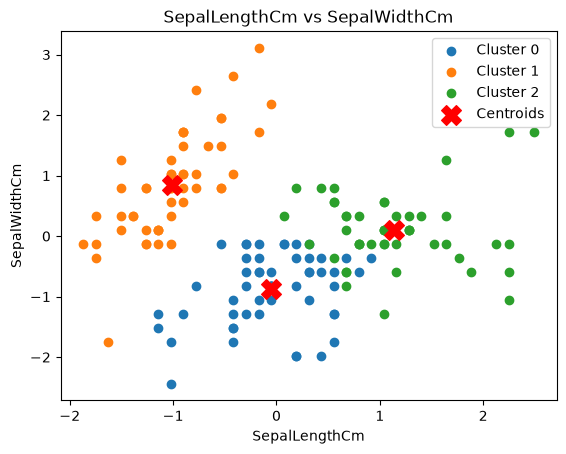

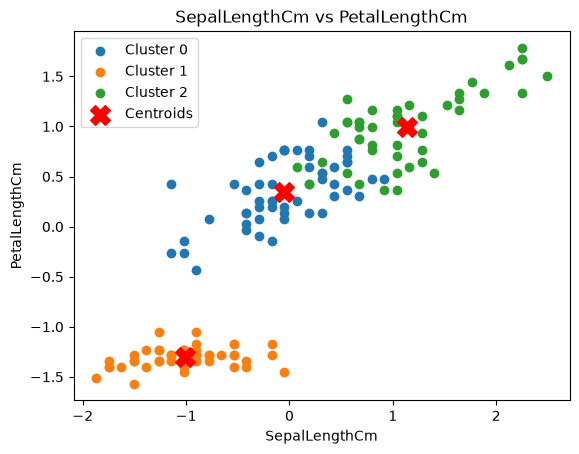

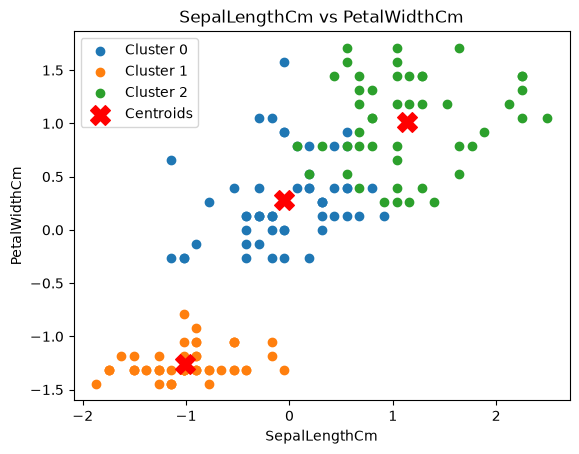

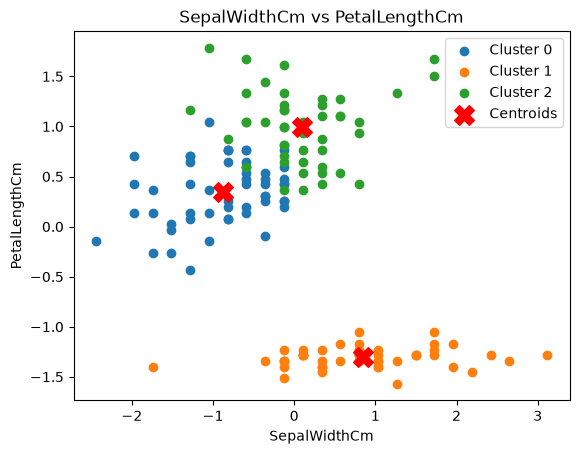

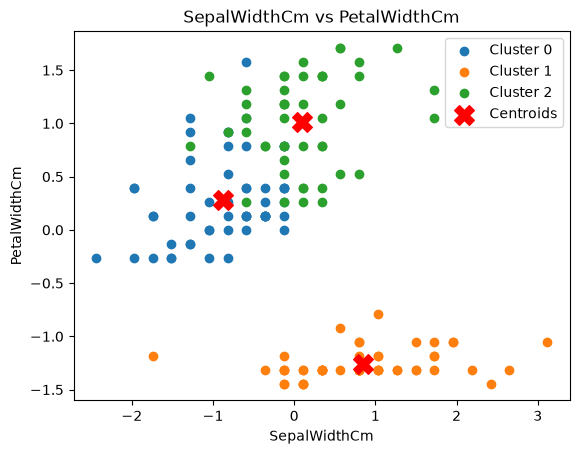

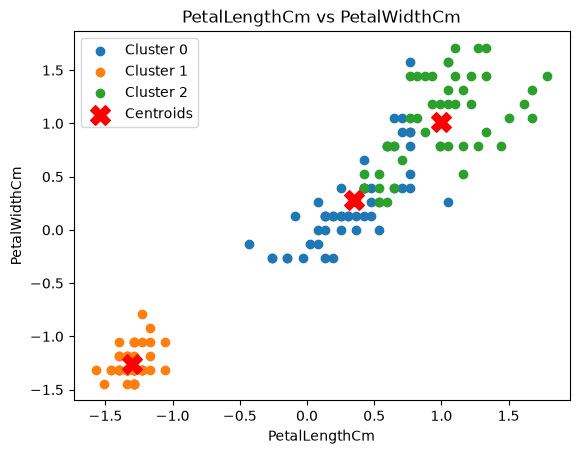

In [29]:
# Visualisation:

cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm' ]

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        x_label = cols[i]
        y_label = cols[j]

        plt.figure()

        for cluster_num in sorted(set(kmeans.labels_)):
            mask = kmeans.labels_ == cluster_num
            plt.scatter(X_scaled[mask,i], X_scaled[mask, j], label = f'Cluster {cluster_num}' )
            
            
        plt.scatter(kmeans.cluster_centers_[:, i], kmeans.cluster_centers_[:, j], c = 'red', marker = "X", s = 200, label = 'Centroids')
        
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(f'{x_label} vs {y_label}')
        plt.legend()
    

In [31]:
iris['cluster'] = kmeans.labels_
iris.head(10)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1
5,5.4,3.9,1.7,0.4,Iris-setosa,1
6,4.6,3.4,1.4,0.3,Iris-setosa,1
7,5.0,3.4,1.5,0.2,Iris-setosa,1
8,4.4,2.9,1.4,0.2,Iris-setosa,1
9,4.9,3.1,1.5,0.1,Iris-setosa,1


In [32]:
comparison = pd.crosstab(iris['Species'], iris['cluster'])
print(comparison)

# Comparison shows KMeans was able to separate Iris setosa cleanly but mixed up the remaining two species in different clusters.

cluster           0   1   2
Species                    
Iris-setosa       0  50   0
Iris-versicolor  39   0  11
Iris-virginica   14   0  36


# Practice Q: 3-4/ Assignment Q:2

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
iris_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio is : {pca.explained_variance_ratio_}')

Explained variance ratio is : [0.72770452 0.23030523]


In [34]:
# PC1 captures 73% of the variance in the dataset and PC2 captures 23% of the variance.
# This means 96% of variance in the dataset was retained even when reduced to 2D.